# GA data exploration



marketing strategy -> suggest platform to promote on, types of campaign/notifications -> increase user engagement & checkouts [could further recommend to target different user demographics]

=== dataframes built ===
- session source
    > identify the platform of ads and campaign promotion that brings user to engage with HH
- campaign impact
    > show restaurant's campaign items as ecommerce funnel - viewed, added to cart, checked out as revenue
- campaigns_outreach
    # 
- time series data; agg_user_activity
    > identify engagement trends in different campaign's time period
- time series data; agg_new_users
- time series data; agg_restaurants
- user demographics
    > possibly find changes in user demographics over time; draw links between campaign success to demographics

#### data cleaning that was done
- for all datasets -> dtype change (all dtype = object by default)

#### data cleaning to be done
session source 
- remove "(data not available)" rows

campaign impact, campaign outreach, agg new users,
- remove "(not set)" rows
- remove "(not set)" rows

user_demographics
- remove "unknown" value rows
- remove "(other)" value rows

### imports


In [ ]:
!pip install plotly --quiet
import plotly.express as px
import pandas as pd
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "../data/marketing/googleAPI/"
agg_new_users = pd.read_parquet(BASE_PATH + "agg_new_users.parquet")
agg_restaurants = pd.read_parquet(BASE_PATH + "agg_restaurants.parquet")
agg_user_activity = pd.read_parquet(BASE_PATH + "agg_user_activity.parquet")
campaign_impact = pd.read_parquet(BASE_PATH + "campaign_impact.parquet")
campaigns_outreach = pd.read_parquet(BASE_PATH + "campaigns_outreach.parquet")
user_demographics = pd.read_parquet(BASE_PATH + "user_demographics.parquet")
session_source = pd.read_parquet(BASE_PATH + "session_source.parquet")


def quick_summary(df):
    print(f"\n{'='*60}")
    print(f" {df}  |  {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"\n{'='*60}")
    print("sample view")
    display(df.sample(3))
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n{'='*60}")
    if len(missing):
        print('\n Missing values:')
        display(missing.to_frame('missing'))
    else:
        print('No missing values.')
    print(f"\n{'='*60}")
    print("dataset info")
    display(df.describe(include='all').T)


# dtype changes

In [4]:
SCHEMA = {
    'session_source': {
        'datetime': ['yearMonth'],
        'category': ['sessionSource'],
        'float': [
            'sessions',
            'sessionKeyEventRate:add_to_cart',
            'sessionKeyEventRate:add_to_wishlist',
            'sessionKeyEventRate:begin_checkout',
            'sessionKeyEventRate:booking',
            'sessionKeyEventRate:ecommerce_purchase',
            'sessionKeyEventRate:in_app_purchase',
        ],
    },
    'campaigns_outreach': {
        'datetime': ['yearMonth'],
        'string':   ['campaignId'],
        'category': ['campaignName'],
        'float':    ['sessions'],
    },
    'campaign_impact': {
        'datetime': ['yearMonth'],
        'string':   ['itemId'],
        'category': ['itemName'],
        'float':    ['itemsViewed', 'itemsAddedToCart', 'itemsPurchased', 'itemRevenue'],
    },
    'agg_new_users': {
        'datetime': ['yearMonth'],
        'category': ['firstUserSourcePlatform'],
        'float':    ['newUsers', 'activeUsers'],
    },
    'agg_user_activity': {
        'datetime': ['yearMonth'],
        'float': [
            'activeUsers', 'engagedSessions', 'sessionsPerUser',
            'userEngagementDuration', 'addToCarts', 'checkouts',
            'ecommercePurchases', 'totalPurchasers',
            'purchaseRevenue', 'totalRevenue',
        ],
    },
    'agg_restaurants': {
        'int':      ['year'],
        'string':   ['itemId'],
        'category': ['itemName'],
    },
    'user_demographics': {
        'datetime': ['yearMonth'],
        'category': ['userAgeBracket', 'userGender'],
        'float': [
            'activeUsers', 'engagedSessions',
            'ecommercePurchases', 'engagementRate', 'purchaseRevenue',
        ],
    },
}

In [5]:
def clean(df, name):
    df = df.copy()
    df.columns = df.columns.str.strip()
    schema = SCHEMA.get(name, {})
    cast_cols = set()

    for col in schema.get('datetime', []):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col].str.strip(), format='%Y%m', errors='coerce')
            cast_cols.add(col)

    for col in schema.get('int', []):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].str.strip(), errors='coerce').astype('Int16')
            cast_cols.add(col)

    for col in schema.get('float', []):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].str.strip(), errors='coerce').astype('float64')
            cast_cols.add(col)

    for col in schema.get('string', []):
        if col in df.columns:
            df[col] = df[col].str.strip().astype('string')
            cast_cols.add(col)

    for col in schema.get('category', []):
        if col in df.columns:
            df[col] = df[col].str.strip().astype('category')
            cast_cols.add(col)

    leftover = [c for c in df.select_dtypes('object').columns if c not in cast_cols]
    if leftover:
        print(f'WARNING [{name}] columns still object (not in schema): {leftover}')
    report = pd.DataFrame({
        'after':  df.dtypes.astype(str),
        'nulls_after': df.isnull().sum(),
        'sample': [
            df[c].dropna().iloc[0] if df[c].notna().any() else None
            for c in df.columns
        ],
    })
    print(report)
    return df


RAW_DATAFRAMES = {
    "agg_new_users": agg_new_users,
    "agg_restaurants": agg_restaurants,
    "agg_user_activity": agg_user_activity,
    "campaign_impact": campaign_impact,
    "campaigns_outreach": campaigns_outreach,
    "user_demographics": user_demographics,
    "session_source": session_source
}

cleaned_frames = {n: clean(RAW_DATAFRAMES[n], n)  for n in RAW_DATAFRAMES}

# CLEANED dataframes
ss = cleaned_frames['session_source']
co = cleaned_frames['campaigns_outreach']
ci = cleaned_frames['campaign_impact']
nu = cleaned_frames['agg_new_users']
ua = cleaned_frames['agg_user_activity']
ar = cleaned_frames['agg_restaurants']
ud = cleaned_frames['user_demographics']

CLEANED_DATAFRAMES = {

}

                                  after  nulls_after               sample
yearMonth                datetime64[ns]            0  2026-01-01 00:00:00
firstUserSourcePlatform        category            0            (not set)
newUsers                        float64            0             835974.0
activeUsers                     float64            0            1108338.0
             after  nulls_after sample
year         Int16            0   2024
itemId      string            0       
itemName  category            0       
                                 after  nulls_after               sample
yearMonth               datetime64[ns]            0  2026-01-01 00:00:00
activeUsers                    float64            0            1704327.0
engagedSessions                float64            0            1863453.0
sessionsPerUser                float64            0             2.362247
userEngagementDuration         float64            0          185744517.0
addToCarts                     float

# data exploration

In [60]:
summary = {
    'Total Sessions (session_source)':    ss['sessions'].sum(),
    'Unique Campaigns':                   co['campaignId'].nunique(),
    'Total Item Revenue ($)':             ci['itemRevenue'].sum(),
    'Total New Users':                    nu['newUsers'].sum(),
    'Total Active Users (activity)':      ua['activeUsers'].sum() if 'activeUsers' in ua else np.nan,
    'Total Purchase Revenue ($)':         ua['purchaseRevenue'].sum() if 'purchaseRevenue' in ua else np.nan,
    'Unique Restaurants (all years)':     ar['itemId'].nunique(),
    'Avg Engagement Rate (demographics)': ud['engagementRate'].mean() if 'engagementRate' in ud else np.nan,
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df['Value'] = summary_df['Value'].apply(lambda x: f'{x:,.2f}')
display(
    summary_df.style
    .set_caption('Summary')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,Value
Total Sessions (session_source),"78,883,231.00"
Unique Campaigns,"8,478.00"
Total Item Revenue ($),"228,445,961.44"
Total New Users,"21,128,044.00"
Total Active Users (activity),"25,376,527.00"
Total Purchase Revenue ($),"1,062,145,630.71"
Unique Restaurants (all years),"8,642.00"
Avg Engagement Rate (demographics),0.68


## session_source

In [12]:
quick_summary(session_source)



       yearMonth           sessionSource sessions  \
0        202512                (direct)  3512945   
1        202510                (direct)  3161626   
2        202508                (direct)  3092304   
3        202511                (direct)  3021541   
4        202509                (direct)  2955042   
...         ...                     ...      ...   
12091    202602           yandex.com.tr        1   
12092    202602  yourarticlelibrary.com        1   
12093    202602      yurikoyamanaka.com        1   
12094    202602              zingat.com        1   
12095    202602              zumiez.com        1   

      sessionKeyEventRate:add_to_cart sessionKeyEventRate:add_to_wishlist  \
0                0.046541292277561985                                   0   
1                0.035418167740270352                                   0   
2                0.041912761487874414                                   0   
3                0.035655978191260686                            

,yearMonth,sessionSource,sessions,sessionKeyEventRate:add_to_cart,sessionKeyEventRate:add_to_wishlist,sessionKeyEventRate:begin_checkout,sessionKeyEventRate:booking,sessionKeyEventRate:ecommerce_purchase,sessionKeyEventRate:in_app_purchase
6863,202405,IGShopping,3,0,0,0,0,0,0
1531,202601,m.cafe.naver.com,107,0.205607476635514,0,0.028037383177570093,0,0,0
8925,202601,at.search.yahoo.com,2,0,0,0,0,0,0



No missing values.

dataset info


,count,unique,top,freq
yearMonth,12096,26,202510,598
sessionSource,12096,2310,(direct),26
sessions,12096,1181,1,3075
sessionKeyEventRate:add_to_cart,12096,1749,0,7725
sessionKeyEventRate:add_to_wishlist,12096,1,0,12096
sessionKeyEventRate:begin_checkout,12096,1351,0,9613
sessionKeyEventRate:booking,12096,836,0,10866
sessionKeyEventRate:ecommerce_purchase,12096,1,0,12096
sessionKeyEventRate:in_app_purchase,12096,1,0,12096


/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_95382/3181889741.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_sources = ss.groupby('sessionSource')['sessions'].sum().nlargest(10).index
/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_95382/3181889741.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for src, grp in ss_top.groupby('sessionSource'):


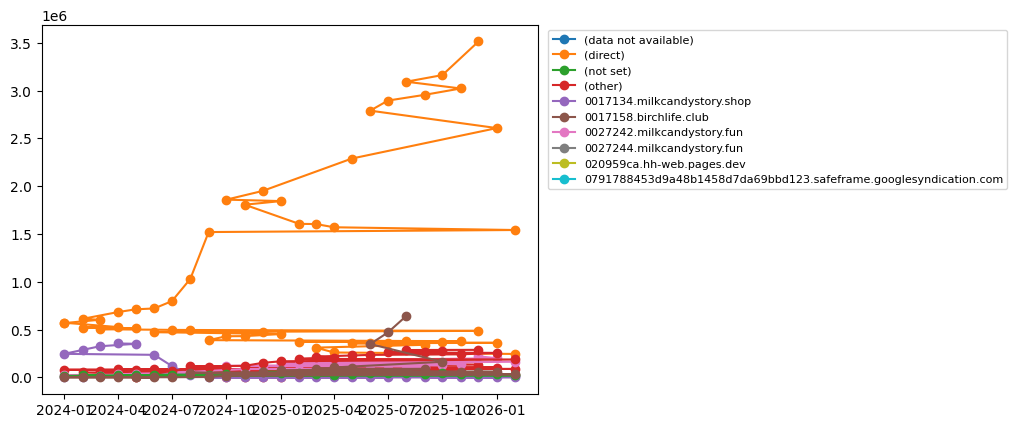

In [34]:
top_sources = ss.groupby('sessionSource')['sessions'].sum().nlargest(10).index
ss_top = ss[ss['sessionSource'].isin(top_sources)]

fig, ax = plt.subplots()
for src, grp in ss_top.groupby('sessionSource'):
    ax.plot(grp['yearMonth'], grp['sessions'], marker='o', label=src)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:10], labels[:10], bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_95382/1651745616.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss[ss['sessionSource'].isin(top_sources)]


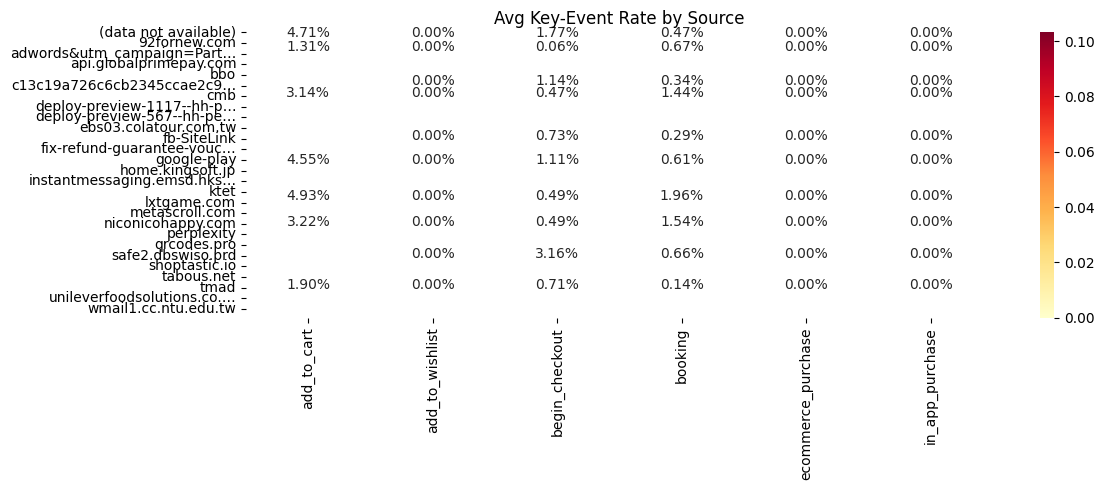

In [35]:
rate_cols     = [c for c in ss.columns if 'sessionKeyEventRate' in c]
funnel_labels = [c.split(':')[-1] for c in rate_cols]

heatmap_data = (
    ss[ss['sessionSource'].isin(top_sources)]
    .groupby('sessionSource')[rate_cols].mean()
)
heatmap_data.columns = funnel_labels

# Truncate long source names on the y-axis
max_len = 25
heatmap_data.index = [s[:max_len] + '…' if len(s) > max_len else s for s in heatmap_data.index]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Avg Key-Event Rate by Source')
plt.tight_layout()
plt.show()

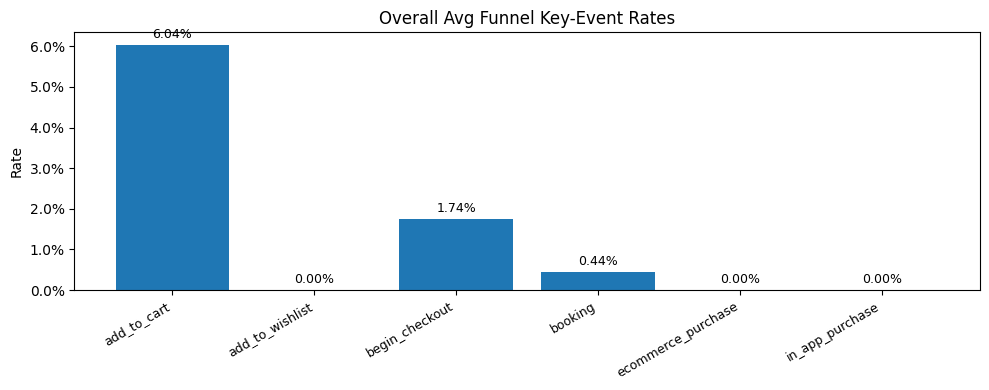

In [37]:
funnel_order = [c for c in [
    'sessionKeyEventRate:add_to_cart',
    'sessionKeyEventRate:add_to_wishlist',
    'sessionKeyEventRate:begin_checkout',
    'sessionKeyEventRate:booking',
    'sessionKeyEventRate:ecommerce_purchase',
    'sessionKeyEventRate:in_app_purchase',
] if c in ss.columns]

funnel_means = ss[funnel_order].mean()
funnel_means.index = [c.split(':')[-1] for c in funnel_means.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(funnel_means.index, funnel_means.values)
ax.set_title('Overall Avg Funnel Key-Event Rates')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Rotate and wrap x-axis tick labels so they don't overlap
ax.set_xticks(range(len(funnel_means.index)))
ax.set_xticklabels(funnel_means.index, rotation=30, ha='right', fontsize=9)

for bar, val in zip(bars, funnel_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## agg_user_activity


## campaigns_outreach

In [6]:
quick_summary(co)


         yearMonth                                 campaignId  \
0      2025-12-01                                  (not set)   
1      2025-10-01                                  (not set)   
2      2025-11-01                                  (not set)   
3      2025-08-01                                  (not set)   
4      2025-09-01                                  (not set)   
...           ...                                        ...   
111523 2026-02-01                                23391503171   
111524 2026-02-01                                23491167316   
111525 2026-02-01                             52520115491884   
111526 2026-02-01                                 6470690326   
111527 2026-02-01  giorgiosriversideroyalorchidsheratonhotel   

                                            campaignName   sessions  
0                                               (direct)  3393168.0  
1                                               (direct)  3031936.0  
2                  

,yearMonth,campaignId,campaignName,sessions
81878,2025-07-01,120212213136680267_v2_s10_e7050_sp_111,tourist_taiwan,3.0
84610,2026-02-01,120234680388540267_v2_s16_e332_i20251124,(not set),3.0
9067,2024-01-01,(not set),TH_BKK_M_PN_MI_N_N_active_20231104_1000_medini...,1380.0



No missing values.

dataset info


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
yearMonth,111528,NaN,NaN,NaN,2025-03-19 15:47:57.985796608,2024-01-01 00:00:00,2024-10-01 00:00:00,2025-05-01 00:00:00,2025-10-01 00:00:00,2026-02-01 00:00:00,NaN
campaignId,111528,8478,(not set),77286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaignName,111528,13204,(not set),5798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sessions,111528.0,NaN,NaN,NaN,1007.771851,1.0,3.0,12.0,105.0,3393168.0,30294.434416


In [ ]:
top_campaigns = co.groupby(['campaignId', 'campaignName'])['sessions'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{n}\n({i})" for (i, n) in top_campaigns.index]
ax.barh(labels[::-1], top_campaigns.values[::-1])
ax.set_title('Top 10 Campaigns by Total Sessions')
ax.set_xlabel('Sessions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_95382/3524979926.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_campaigns = co.groupby(['campaignId', 'campaignName'])['sessions'].sum().nlargest(10)
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fad382c8b20>>
Traceback (most recent call last):
  File "/Users/liyunling/Downloads/GitHub/OPE/venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


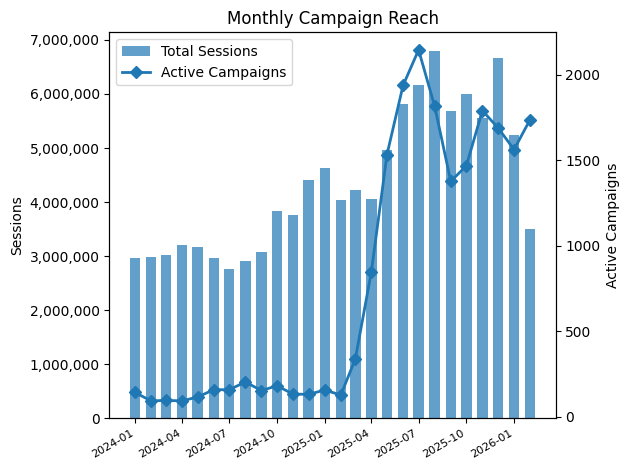

In [8]:
monthly_co = co.groupby('yearMonth').agg(
    total_sessions=('sessions', 'sum'),
    active_campaigns=('campaignId', 'nunique')
).reset_index()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(monthly_co['yearMonth'], monthly_co['total_sessions'],
         alpha=0.7, label='Total Sessions', width=20)
ax2.plot(monthly_co['yearMonth'], monthly_co['active_campaigns'],
         marker='D', linewidth=2, label='Active Campaigns')
ax1.set_title('Monthly Campaign Reach')
ax1.set_ylabel('Sessions')
ax2.set_ylabel('Active Campaigns')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, lbls, loc='upper left')

plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## campaign_impact


In [ ]:
quick_summary(ci)

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/1674133639.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ci.groupby(['itemId', 'itemName'])


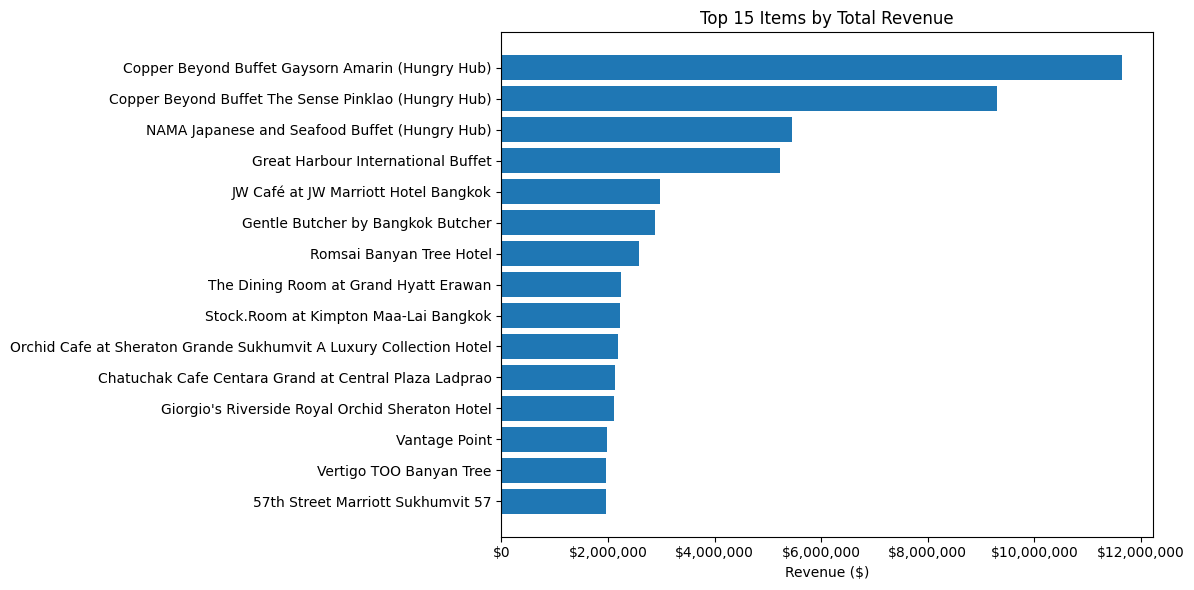

In [14]:
top_items = (
    ci.groupby(['itemId', 'itemName'])
    .agg(total_revenue=('itemRevenue', 'sum'),
         total_purchased=('itemsPurchased', 'sum'),
         total_viewed=('itemsViewed', 'sum'))
    .sort_values('total_revenue', ascending=False)
    .head(15).reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_items['itemName'][::-1], top_items['total_revenue'][::-1])
ax.set_title('Top 15 Items by Total Revenue')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

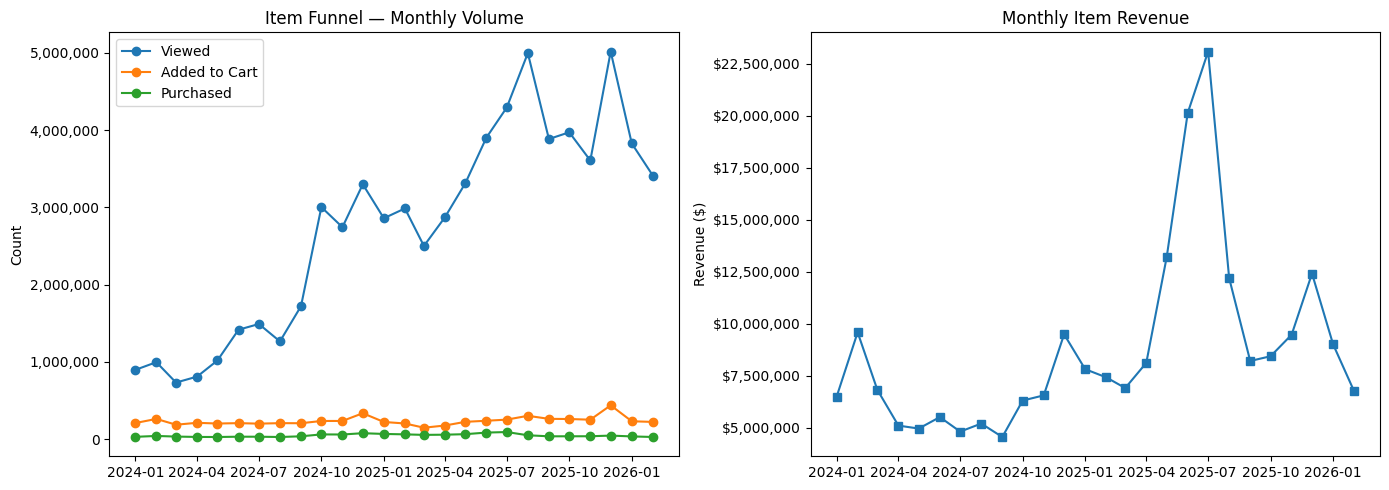

In [12]:
ci['cart_rate']     = ci['itemsAddedToCart'] / ci['itemsViewed'].replace(0, np.nan)
ci['purchase_rate'] = ci['itemsPurchased']   / ci['itemsViewed'].replace(0, np.nan)

monthly_ci = ci.groupby('yearMonth')[['itemsViewed','itemsAddedToCart','itemsPurchased','itemRevenue']].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, label in zip(
    ['itemsViewed', 'itemsAddedToCart', 'itemsPurchased'],
     ['Viewed', 'Added to Cart', 'Purchased']
):
    axes[0].plot(monthly_ci.index, monthly_ci[col], marker='o', label=label)
axes[0].set_title('Item Funnel — Monthly Volume')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].plot(monthly_ci.index, monthly_ci['itemRevenue'], marker='s')
axes[1].set_title('Monthly Item Revenue')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## agg_new_users

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/2879816845.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_platforms = nu.groupby('firstUserSourcePlatform')['newUsers'].sum().nlargest(6).index
/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/2879816845.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for platform, grp in nu_top.groupby('firstUserSourcePlatform'):


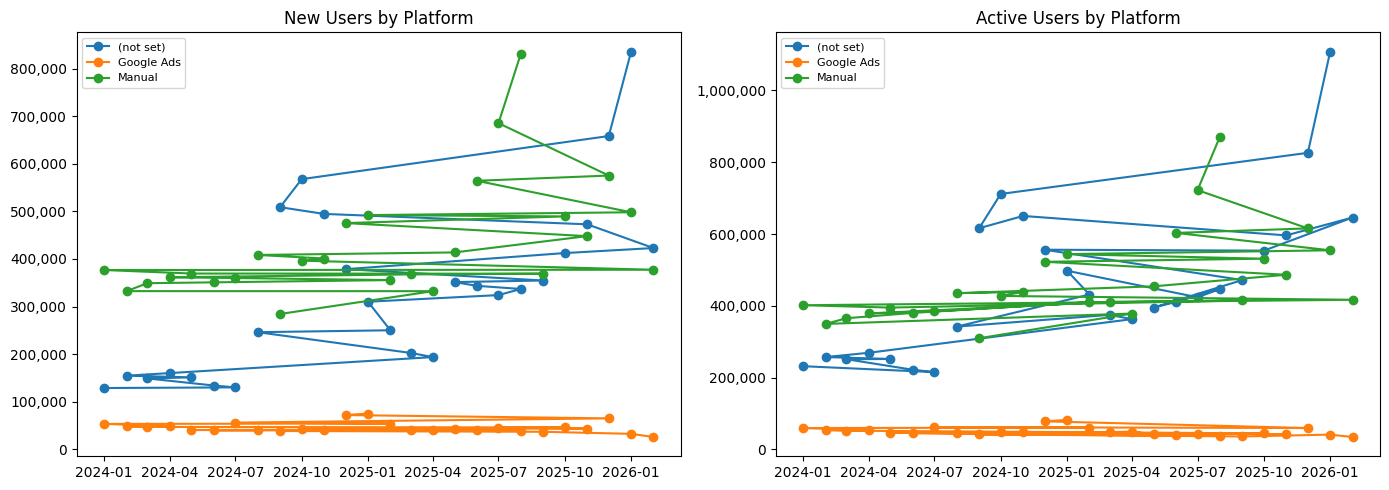

In [20]:
top_platforms = nu.groupby('firstUserSourcePlatform')['newUsers'].sum().nlargest(6).index
nu_top = nu[nu['firstUserSourcePlatform'].isin(top_platforms)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for platform, grp in nu_top.groupby('firstUserSourcePlatform'):
    axes[0].plot(grp['yearMonth'], grp['newUsers'],    marker='o', label=platform)
    axes[1].plot(grp['yearMonth'], grp['activeUsers'], marker='o', label=platform)
for ax, title in zip(axes, ['New Users by Platform', 'Active Users by Platform']):
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/2133577553.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_totals = nu.groupby('firstUserSourcePlatform')['newUsers'].sum().sort_values(ascending=False)


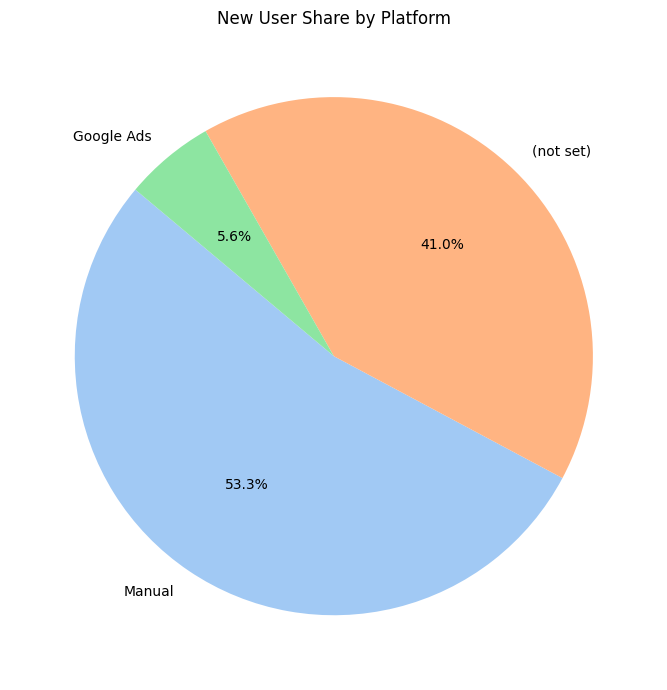

In [21]:
platform_totals = nu.groupby('firstUserSourcePlatform')['newUsers'].sum().sort_values(ascending=False)
threshold = platform_totals.sum() * 0.02
large = platform_totals[platform_totals >= threshold].copy()
small = platform_totals[platform_totals < threshold]
if len(small):
    large['Other'] = small.sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(large.values, labels=large.index, autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette('pastel'))
ax.set_title('New User Share by Platform')
plt.tight_layout()
plt.show()

# agg_user_activity

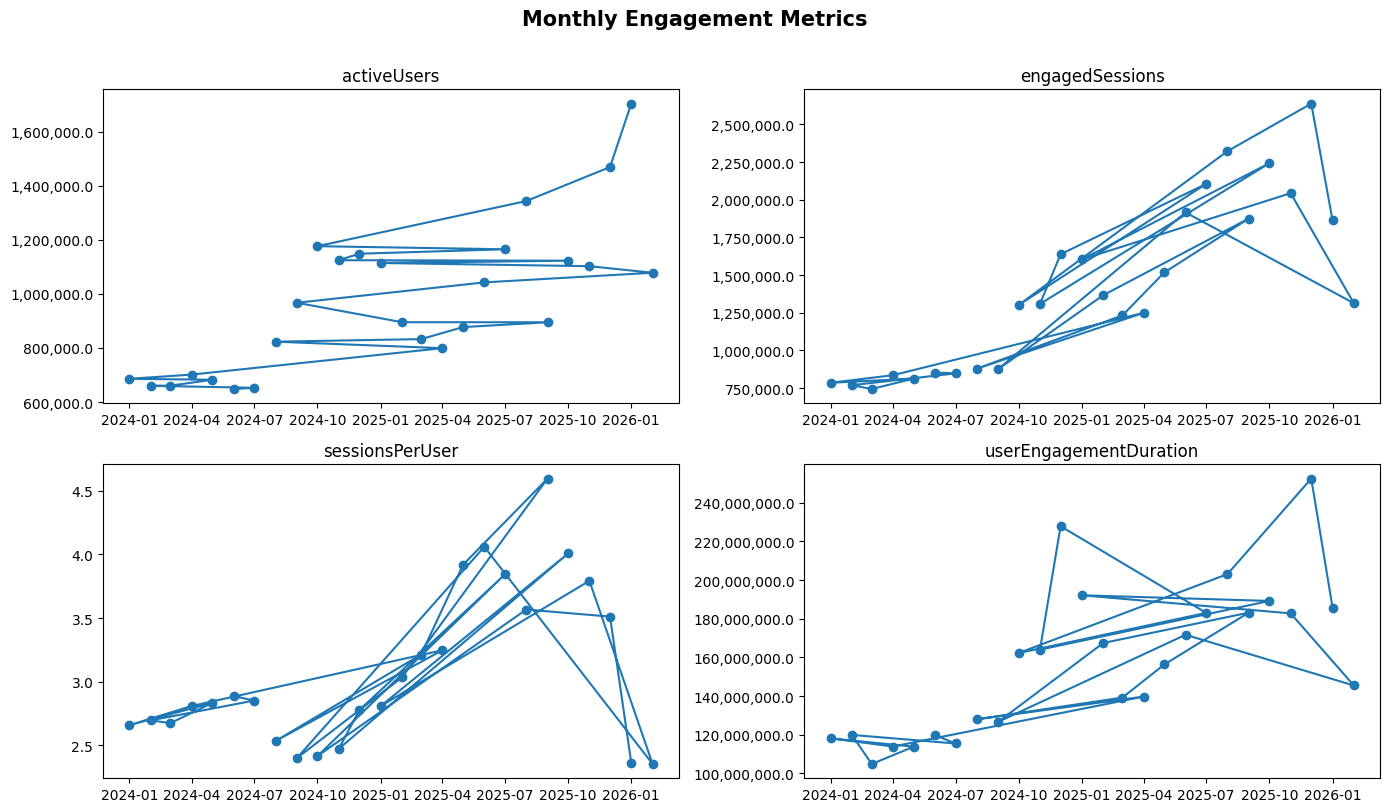

In [23]:
eng_cols = [c for c in ['activeUsers','engagedSessions','sessionsPerUser','userEngagementDuration'] if c in ua.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), eng_cols):
    ax.plot(ua['yearMonth'], ua[col], marker='o')
    ax.set_title(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))
for ax in axes.flatten()[len(eng_cols):]:
    ax.set_visible(False)
plt.suptitle('Monthly Engagement Metrics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.line(
    ua.melt(id_vars='yearMonth', value_vars=ecom_cols, var_name='metric', value_name='count'),
    x='yearMonth',
    y='count',
    color='metric',
    markers=True,
    title='Ecommerce Funnel — Monthly',
    labels={'yearMonth': '', 'count': 'Count', 'metric': 'Metric'},
)

fig.update_layout(
    yaxis_tickformat=',.0f',
    legend=dict(orientation='h', yanchor='bottom', y=-0.3, xanchor='left', x=0),
    margin=dict(t=50, b=80, l=60, r=20),
    hovermode='x unified', 

fig.show()

In [37]:
import plotly.graph_objects as go

num_cols = ua.select_dtypes(include='number').columns.tolist()
corr = ua[num_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.where(~mask)

fig = go.Figure(go.Heatmap(
    z=corr_masked.values,
    x=corr_masked.columns.tolist(),
    y=corr_masked.index.tolist(),
    colorscale='RdBu',
    zmid=0,
    text=corr_masked.round(2).values,
    texttemplate='%{text}',
    hovertemplate='%{y} × %{x}<br>Correlation: %{z:.2f}<extra></extra>',
    colorbar=dict(title='Correlation'),
))

fig.update_layout(
    title='Metric Correlation Matrix',
    width=700, height=650,
    xaxis=dict(tickangle=30),
    margin=dict(t=60, l=150, r=20, b=100),
)

fig.show()

# user_demographics

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/2310113497.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ud[~ud['userAgeBracket'].isin(['unknown', '(other)'])]


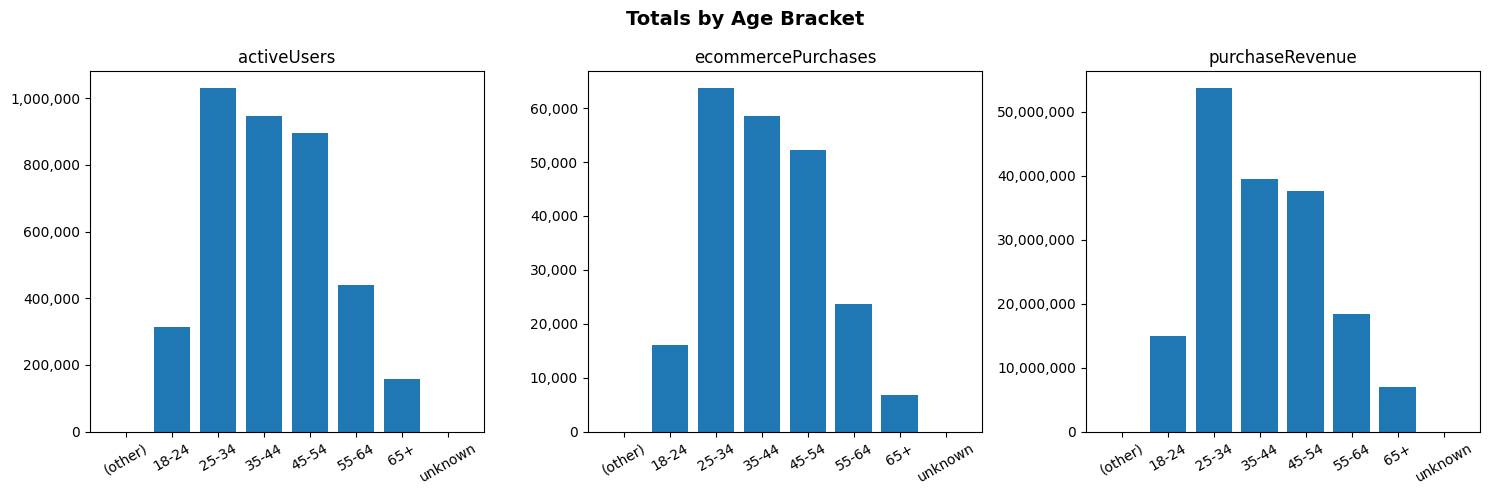

In [55]:
# removed unknown in graph first
age_agg = (
    ud[~ud['userAgeBracket'].isin(['unknown', '(other)'])]
    .groupby('userAgeBracket')[['activeUsers','ecommercePurchases','purchaseRevenue']]
    .sum()
    .reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['activeUsers','ecommercePurchases','purchaseRevenue']):
    ax.bar(age_agg['userAgeBracket'], age_agg[col])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('Totals by Age Bracket', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/3002959841.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rev_pivot = ud_known.pivot_table(index='userAgeBracket', columns='userGender',


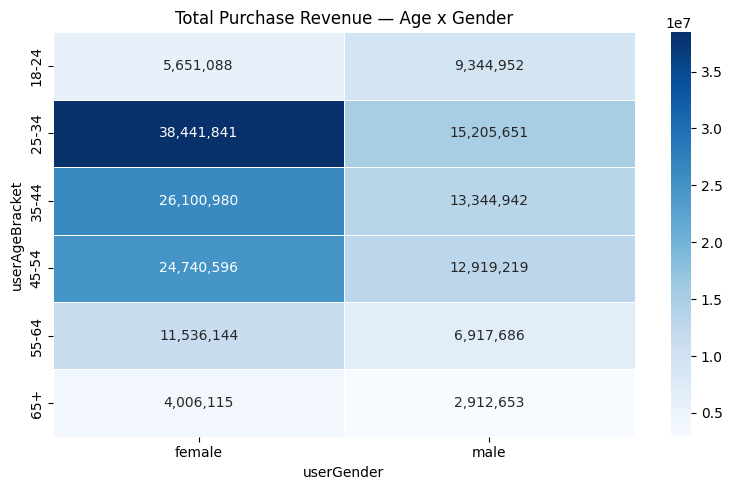

In [54]:
# age x gender to revenue
ud_known = (
    ud[~ud['userAgeBracket'].str.lower().isin(['unknown', 'unspecified', 'none', '(other)'])]
    .pipe(lambda x: x[~x['userGender'].str.lower().isin(['unknown', 'unspecified', 'none', ''])])
    .assign(
        userAgeBracket=lambda x: x['userAgeBracket'].cat.remove_unused_categories(),
        userGender=lambda x: x['userGender'].cat.remove_unused_categories(),
    )
)

rev_pivot = ud_known.pivot_table(index='userAgeBracket', columns='userGender',
                                 values='purchaseRevenue', aggfunc='sum')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(rev_pivot, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Total Purchase Revenue — Age x Gender')
plt.tight_layout()
plt.show()

In [57]:
if 'engagementRate' in ud_known.columns:
    monthly_eng = (
        ud_known.groupby(['yearMonth', 'userAgeBracket'])['engagementRate']
        .mean()
        .reset_index()
    )

    fig = px.line(
        monthly_eng,
        x='yearMonth',
        y='engagementRate',
        color='userAgeBracket',
        markers=True,
        title='Avg Engagement Rate by Age Bracket (Monthly)',
        labels={
            'yearMonth':      '',
            'engagementRate': 'Engagement Rate',
            'userAgeBracket': 'Age Bracket',
        },
    )

    fig.update_layout(
        yaxis_tickformat='.0%',
        hovermode='x unified',
        legend=dict(title='Age Bracket', orientation='v'),
        margin=dict(t=60, r=20, b=60, l=60),
    )

    fig.show()

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_111/4007022475.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ud_known.groupby(['yearMonth', 'userAgeBracket'])['engagementRate']


# agg_restaurants

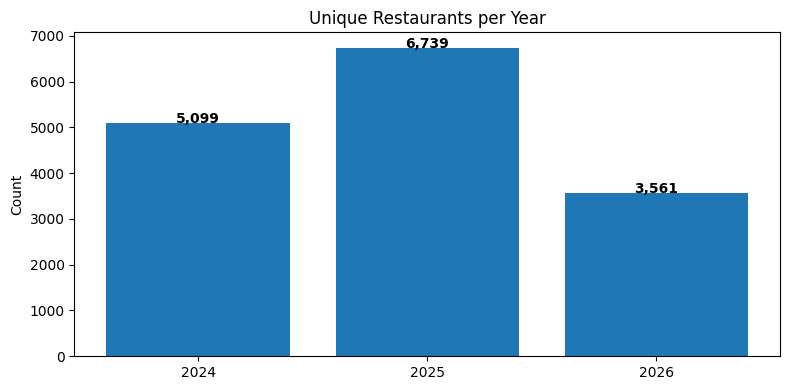

In [39]:
rest_per_year = ar.groupby('year')['itemId'].nunique().reset_index(name='unique_restaurants')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rest_per_year['year'].astype(str), rest_per_year['unique_restaurants'])
ax.set_title('Unique Restaurants per Year')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, rest_per_year['unique_restaurants']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

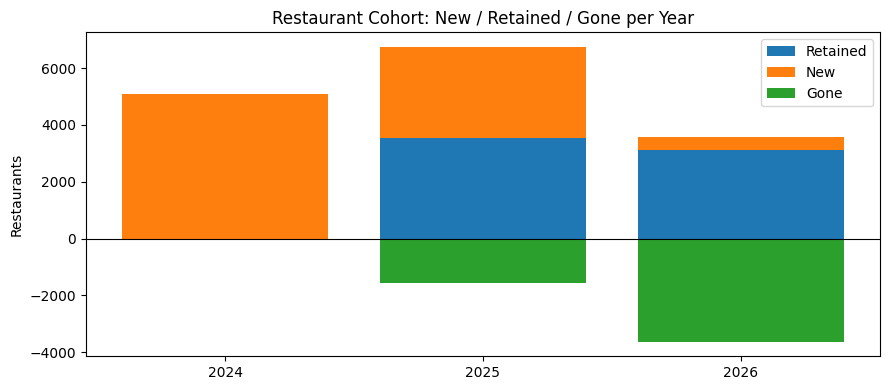

,year,new,retained,gone
0,2024,5099,0,0
1,2025,3202,3537,1562
2,2026,442,3119,3620


In [ ]:
## since up until 2024 dataset, all restaurants from 2024 counted as new
# # New / retained / gone YoY
# gone == restaurants that were present in the previous year but have disappeared from the current year's data

years = sorted(ar['year'].dropna().unique())
sets  = {y: set(ar[ar['year'] == y]['itemId']) for y in years}

rows = []
for i, yr in enumerate(years):
    if i == 0:
        rows.append({'year': str(yr), 'new': len(sets[yr]), 'retained': 0, 'gone': 0})
    else:
        prev, curr = sets[years[i-1]], sets[yr]
        rows.append({'year': str(yr), 'new': len(curr - prev),
                     'retained': len(curr & prev), 'gone': len(prev - curr)})

cohort_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cohort_df['year'], cohort_df['retained'], label='Retained')
ax.bar(cohort_df['year'], cohort_df['new'], bottom=cohort_df['retained'], label='New')
ax.bar(cohort_df['year'], -cohort_df['gone'], label='Gone')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Restaurant Cohort: New / Retained / Gone per Year')
ax.set_ylabel('Restaurants')
ax.legend()
plt.tight_layout()
plt.show()
display(cohort_df)